# MP1 — Peierls instability: tight-binding band structures

Companion to Mini-project 1, §1. Pure tight-binding (no DFT): the uniform 1D
chain $\varepsilon(k)=-2t\cos ka$ is a half-filled **metal**; dimerizing the
chain (a $2k_F$ distortion, $t\to t\pm\delta t$) folds the zone and opens a
gap $2\Delta=4\,\delta t$ exactly at $k_F$, turning it into an **insulator**.
Requires `numpy`, `matplotlib`.

k_F = pi/2,  E_F = 0
dimerized gap 2Delta = 2|t1-t2| = 0.80  (= 4*dt = 0.80)


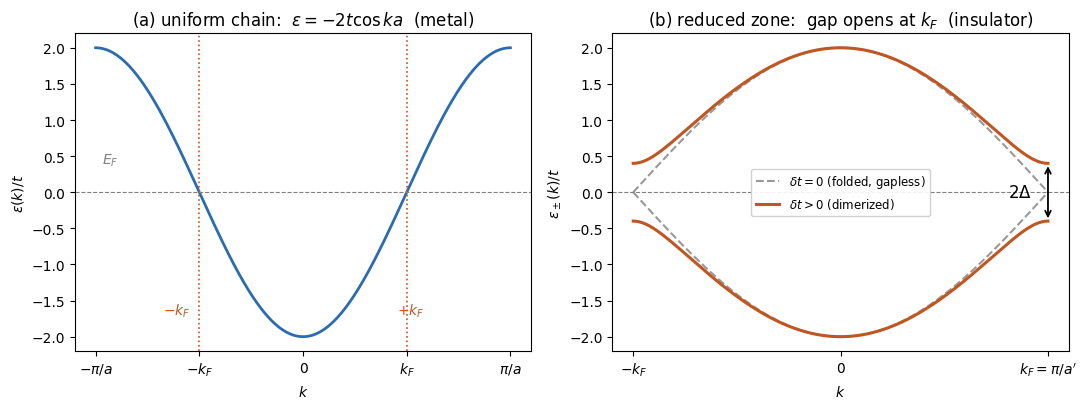

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1D Peierls tight-binding model (a=1) ---
t  = 1.0          # uniform hopping
dt = 0.20         # dimerization: t1=t+dt, t2=t-dt  (dt proportional to distortion u0)
t1, t2 = t + dt, t - dt
kF = np.pi / 2    # half-filling Fermi point (a=1)

# (a) uniform chain, extended zone: eps(k) = -2t cos(k)
k_ext = np.linspace(-np.pi, np.pi, 800)
eps_uniform = -2 * t * np.cos(k_ext)

# (b) reduced zone k in [-pi/2, pi/2]; two-band eps_pm(k)
k_red = np.linspace(-kF, kF, 800)
def eps_pm(k, t1, t2):
    h = np.sqrt(t1**2 + t2**2 + 2 * t1 * t2 * np.cos(2 * k))  # a'=2
    return +h, -h
ep_d, em_d = eps_pm(k_red, t1, t2)          # dimerized (gapped)
ep_0, em_0 = eps_pm(k_red, t, t)            # delta t = 0 (folded, gapless)
gap = 2 * abs(t1 - t2)
print(f"k_F = pi/2,  E_F = 0")
print(f"dimerized gap 2Delta = 2|t1-t2| = {gap:.2f}  (= 4*dt = {4*dt:.2f})")

fig, (axa, axb) = plt.subplots(1, 2, figsize=(11, 4.2))

# panel (a): uniform metal
axa.plot(k_ext, eps_uniform, color='#2b6cb0', lw=2)
axa.axhline(0, color='gray', ls='--', lw=0.8)
for s in (-1, 1):
    axa.axvline(s * kF, color='#c05621', ls=':', lw=1.2)
axa.annotate('$E_F$', xy=(-np.pi, 0), xytext=(-np.pi+0.1, 0.4), color='gray')
axa.annotate('$+k_F$', xy=(kF, 0), xytext=(kF-0.15, -1.7), color='#c05621')
axa.annotate('$-k_F$', xy=(-kF, 0), xytext=(-kF-0.55, -1.7), color='#c05621')
axa.set_xticks([-np.pi, -kF, 0, kF, np.pi])
axa.set_xticklabels([r'$-\pi/a$', r'$-k_F$', '0', r'$k_F$', r'$\pi/a$'])
axa.set_xlabel('$k$'); axa.set_ylabel(r'$\varepsilon(k)/t$')
axa.set_title(r'(a) uniform chain:  $\varepsilon=-2t\cos ka$  (metal)')

# panel (b): folded vs dimerized
axb.plot(k_red, ep_0, color='0.6', ls='--', lw=1.5, label=r'$\delta t=0$ (folded, gapless)')
axb.plot(k_red, em_0, color='0.6', ls='--', lw=1.5)
axb.plot(k_red, ep_d, color='#c05621', lw=2.2, label=r'$\delta t>0$ (dimerized)')
axb.plot(k_red, em_d, color='#c05621', lw=2.2)
axb.axhline(0, color='gray', ls='--', lw=0.8)
# gap arrow at zone boundary
axb.annotate('', xy=(kF, gap/2), xytext=(kF, -gap/2),
             arrowprops=dict(arrowstyle='<->', color='k', lw=1.3))
axb.text(kF-0.12, 0, r'$2\Delta$', ha='right', va='center', fontsize=12)
axb.set_xticks([-kF, 0, kF])
axb.set_xticklabels([r'$-k_F$', '0', r'$k_F=\pi/a^\prime$'])
axb.set_xlabel('$k$'); axb.set_ylabel(r'$\varepsilon_\pm(k)/t$')
axb.set_title(r'(b) reduced zone:  gap opens at $k_F$  (insulator)')
axb.legend(loc='center', fontsize=8.5, framealpha=0.9)

fig.tight_layout()
fig.savefig('../static/img/MP1-peierls-bands.png', dpi=120)
plt.show()

**Read-off.** Panel (a): the uniform cosine band crosses $E_F=0$ at
$\pm k_F=\pm\pi/2a$ — a metal. Panel (b): in the doubled-cell reduced zone the
old Fermi point lands on the new boundary $k_F=\pi/a'$. For $\delta t=0$ the two
bands just touch (the folded metal); for $\delta t>0$ a gap
$2\Delta=2|t_1-t_2|=4\,\delta t$ opens right at $E_F$, the occupied band drops,
and the chain lowers its electronic energy — the Peierls mechanism.

## Standing waves: the gap and the charge modulation

The same physics in **real space**. The $2k_F$ potential mixes the degenerate
travelling waves $e^{\pm ik_Fx}$ into standing waves $\psi_\pm\propto\cos,\sin(k_Fx)$,
whose densities $|\psi_\pm|^2=1\pm\cos(2k_Fx)$ are **no longer flat** — charge
piles up periodically. The split between them is the gap.

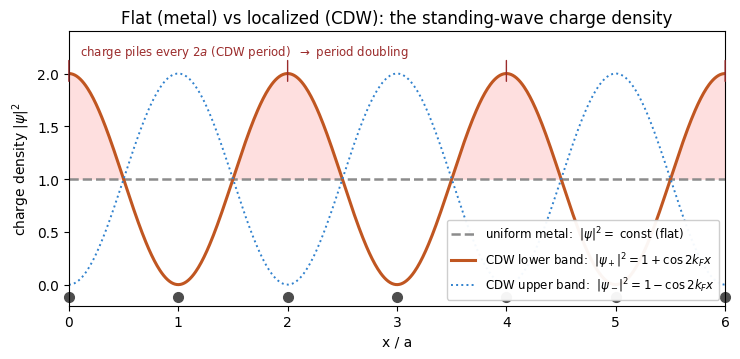

psi_+ heaps charge ON the ion rows (low potential) -> lower energy; psi_- between them -> higher. The split is the gap.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# half-filled chain: k_F = pi/2a, so 2k_F = pi/a and the CDW period is 2a
a = 1.0
kF = np.pi / (2*a)
x = np.linspace(0, 6*a, 700)
flat   = np.ones_like(x)               # |e^{ikx}|^2 = const  (traveling wave, metal)
dens_p = 1 + np.cos(2*kF*x)            # |psi_+|^2 = 1 + cos(2k_F x)  (standing wave)
dens_m = 1 - np.cos(2*kF*x)            # |psi_-|^2 = 1 - cos(2k_F x)

fig, ax = plt.subplots(figsize=(7.5, 3.7))
ax.axhline(1, color='0.55', ls='--', lw=1.8,
           label=r'uniform metal:  $|\psi|^2=$ const (flat)')
ax.plot(x, dens_p, color='#c05621', lw=2.2,
        label=r'CDW lower band:  $|\psi_+|^2=1+\cos 2k_Fx$')
ax.fill_between(x, 1, dens_p, where=dens_p > 1, color='#fed7d7', alpha=0.8)
ax.plot(x, dens_m, color='#3182ce', lw=1.4, ls=':',
        label=r'CDW upper band:  $|\psi_-|^2=1-\cos 2k_Fx$')
# ion sites (every a); charge of psi_+ piles every 2a -> period doubling
ions = np.arange(0, 6.001*a, a)
ax.plot(ions, np.full_like(ions, -0.12), 'o', color='0.3', ms=7, clip_on=False)
for xc in np.arange(0, 6.001*a, 2*a):
    ax.annotate('', xy=(xc, 1.9), xytext=(xc, 2.15),
                arrowprops=dict(arrowstyle='-', color='#9b2c2c', lw=1))
ax.text(0.1, 2.18, r'charge piles every $2a$ (CDW period)  $\rightarrow$ period doubling',
        fontsize=8.5, color='#9b2c2c')
ax.set_xlabel('x / a'); ax.set_ylabel(r'charge density $|\psi|^2$')
ax.set_ylim(-0.2, 2.4); ax.set_xlim(0, 6)
ax.set_title('Flat (metal) vs localized (CDW): the standing-wave charge density')
ax.legend(loc='lower right', fontsize=8.5, framealpha=0.95)
fig.tight_layout()
fig.savefig('../static/img/MP1-peierls-density.png', dpi=120)
plt.show()
print("psi_+ heaps charge ON the ion rows (low potential) -> lower energy;",
      "psi_- between them -> higher. The split is the gap.")

**Flat → localized.** A travelling wave has uniform $|\psi|^2$ (flat dashed line
— a metal, charge spread evenly). The standing wave $\psi_+$ **heaps charge on the
ion rows** (orange humps, period $2a$ = the doubled CDW cell), $\psi_-$ between them.
Filling the lower one both **opens the gap** and **localizes the charge** — this is
the charge-density wave. The energy difference of the two standing waves,
$E_\pm=\varepsilon_0\pm V_{2k_F}$, gives the gap $2\Delta=2|V_{2k_F}|\propto u$ directly.